# Hand Gesture Recognition

In [1]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from scipy.fft import fft, fftfreq

In [2]:
from enum import IntEnum


base_dir = '../recordings/'
num_classes = 7
class Classes(IntEnum):
    NEUTRAL = 0,
    FIST = 1,
    INDEX = 2,
    MIDDLE = 3,
    OK = 4,
    PEACE = 5,
    THUMB = 6
    
# structure: recordings/date/data/*.csv
files = [[] for _ in range(num_classes)]

for date_dir, _, filenames in os.walk(base_dir):
    if date_dir.endswith('data'):
        for filename in filenames:
            if not filename.startswith('fft'):
                continue
            if filename.find('neutral') != -1:
                files[Classes.NEUTRAL].append(os.path.join(date_dir, filename))
            elif filename.find('fist') != -1:
                files[Classes.FIST].append(os.path.join(date_dir, filename))
            elif filename.find('index') != -1:
                files[Classes.INDEX].append(os.path.join(date_dir, filename))
            elif filename.find('middle') != -1:
                files[Classes.MIDDLE].append(os.path.join(date_dir, filename))
            elif filename.find('ok') != -1:
                files[Classes.OK].append(os.path.join(date_dir, filename))
            elif filename.find('peace') != -1:
                files[Classes.PEACE].append(os.path.join(date_dir, filename))
            elif filename.find('thumb') != -1:
                files[Classes.THUMB].append(os.path.join(date_dir, filename))

print(files)      

[['../recordings/05_12_24/data/fft_teacher_neutral_0.csv', '../recordings/05_12_24/data/fft_luka_neutral_0.csv', '../recordings/15_12_24/data/fft_gilbert_neutral_0.csv', '../recordings/15_12_24/data/fft_nad_neutral_0.csv'], ['../recordings/05_12_24/data/fft_teacher_fist_0.csv', '../recordings/05_12_24/data/fft_luka_fist_0.csv', '../recordings/15_12_24/data/fft_gilbert_fist_0.csv', '../recordings/15_12_24/data/fft_nad_fist_0.csv'], ['../recordings/05_12_24/data/fft_luka_index_0.csv', '../recordings/05_12_24/data/fft_teacher_index_0.csv', '../recordings/15_12_24/data/fft_gilbert_index_0.csv', '../recordings/15_12_24/data/fft_nad_index_0.csv'], ['../recordings/05_12_24/data/fft_luka_middle_0.csv', '../recordings/05_12_24/data/fft_teacher_middle_0.csv', '../recordings/15_12_24/data/fft_gilbert_middle_0.csv', '../recordings/15_12_24/data/fft_nad_middle_0.csv'], ['../recordings/05_12_24/data/fft_luka_ok_0.csv', '../recordings/05_12_24/data/fft_teacher_ok_0.csv', '../recordings/15_12_24/data/

Our initial static gesture recording includes 7 classes: neutral, fist, index finger, middle finger, ok, peace, thumb.

In [3]:
def read_dataframe_and_remove_unnecessary_columns(file):
    df = pd.read_csv(file, header=None)
    df = pd.concat([df.iloc[:, (i*16)+1:(i*16)+4] for i in range(0, 4)], axis=1)
    return df

In [4]:
neutral_df = [read_dataframe_and_remove_unnecessary_columns(file) for file in files[Classes.NEUTRAL]]
fist_df = [read_dataframe_and_remove_unnecessary_columns(file) for file in files[Classes.FIST]]
index_df = [read_dataframe_and_remove_unnecessary_columns(file) for file in files[Classes.INDEX]]
middle_df = [read_dataframe_and_remove_unnecessary_columns(file) for file in files[Classes.MIDDLE]]
ok_df = [read_dataframe_and_remove_unnecessary_columns(file) for file in files[Classes.OK]]
peace_df = [read_dataframe_and_remove_unnecessary_columns(file) for file in files[Classes.PEACE]]
thumb_df = [read_dataframe_and_remove_unnecessary_columns(file) for file in files[Classes.THUMB]]

In [5]:
for df in neutral_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.NEUTRAL
for df in fist_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.FIST
for df in index_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.INDEX
for df in middle_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.MIDDLE
for df in ok_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.OK
for df in peace_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.PEACE
for df in thumb_df:
    df.drop_duplicates(inplace=True)
    df['class'] = Classes.THUMB

In [6]:
def print_min_df_len(dfs):
    min_len = min([len(df_) for df in dfs for df_ in df])
    return min_len

min_len = print_min_df_len([neutral_df, fist_df, index_df, middle_df, ok_df, peace_df, thumb_df])
print(min_len)

3290


Optional subsampling:

In [7]:
num_samples = min_len

neutral_df = pd.concat([df.sample(num_samples) for df in neutral_df])
fist_df = pd.concat([df.sample(num_samples) for df in fist_df])
index_df = pd.concat([df.sample(num_samples) for df in index_df])
middle_df = pd.concat([df.sample(num_samples) for df in middle_df])
ok_df = pd.concat([df.sample(num_samples) for df in ok_df])
peace_df = pd.concat([df.sample(num_samples) for df in peace_df])
thumb_df = pd.concat([df.sample(num_samples) for df in thumb_df])
# neutral_df = neutral_df[0].sample(num_samples)
# fist_df = fist_df[0].sample(num_samples)
# index_df = index_df[0].sample(num_samples)
# middle_df = middle_df[0].sample(num_samples)
# ok_df = ok_df[0].sample(num_samples)
# peace_df = peace_df[0].sample(num_samples)
# thumb_df = thumb_df[0].sample(num_samples)

In [8]:
len(neutral_df), len(fist_df), len(index_df), len(middle_df), len(ok_df), len(peace_df), len(thumb_df)

(13160, 13160, 13160, 13160, 13160, 13160, 13160)

In [9]:
neutral_df.head()

,1,2,3,17,18,19,33,34,35,49,50,51,class
8182,46,73,36,46,13,10,66,17,12,62,45,22,0
3651,44,29,24,70,29,18,66,17,40,15,24,24,0
625,46,51,9,17,22,6,42,21,35,121,11,29,0
805,55,61,22,32,9,37,67,46,43,97,51,24,0
5985,60,27,13,44,28,4,106,62,65,22,6,13,0


In [10]:
fist_df.head()

,1,2,3,17,18,19,33,34,35,49,50,51,class
3764,513,48,78,341,159,91,312,151,81,492,184,94,1
10336,235,274,34,147,59,19,148,43,15,203,117,24,1
362,272,169,48,79,39,60,161,148,38,332,140,83,1
4693,650,185,57,115,68,45,109,57,22,504,75,46,1
2149,427,51,111,48,46,16,137,119,95,209,146,35,1


Combine dataframes

In [ ]:
df = pd.concat([neutral_df, fist_df, index_df, middle_df, ok_df, peace_df, thumb_df], ignore_index=True)
df = df.sample(frac=1).reset_index(drop=True)

print(df.head())
print(df.iloc[:, -1].value_counts())

    1   2   3  17  18  19   33  34  35   49  50  51  class
0  46  73  36  46  13  10   66  17  12   62  45  22      0
1  44  29  24  70  29  18   66  17  40   15  24  24      0
2  46  51   9  17  22   6   42  21  35  121  11  29      0
3  55  61  22  32   9  37   67  46  43   97  51  24      0
4  60  27  13  44  28   4  106  62  65   22   6  13      0
class
0    13160
1    13160
2    13160
3    13160
4    13160
5    13160
6    13160
Name: count, dtype: int64


In [12]:
sensor_data = df.iloc[:, :-1]
labels = df.iloc[:, -1]

# Data visualization

## Sensor signals

In [13]:
from scipy import signal
from scipy.signal import butter
from numpy import mean, std

lf = 15
hf = 400
fs = 1150
trim = 4*8*5
bandpass_order = 4
outlier_rejection_stds = 6

def _remove_outliers(data):
    data_mean, data_std = mean(data.flatten()), std(data.flatten())
    cut_off = data_std * outlier_rejection_stds
    lower, upper = data_mean - cut_off, data_mean + cut_off

    outliers_removed = [x if x >= lower and x <= upper else 0.0 for x in data]
    return outliers_removed

def _remove_artefact(data):
    data[:trim] = 0
    return data

def preprocess_data(data):
    sos = butter(bandpass_order, (lf, hf), btype="bandpass", fs=fs, output="sos")
    proc_data = signal.sosfilt(sos, data) # f
    proc_data = _remove_artefact(proc_data)
    # proc_data = _remove_outliers(proc_data)
    return proc_data


plot_all_timeline = False
num_sensors = 4

def plot_time_signals(dataframe, row_index, title):
    row_data = dataframe.iloc[row_index, :-1]

    # Split the row into 8 groups corresponding to sensors
    signals = np.array_split(row_data.values, num_sensors)

    # Plot each sensor's signal
    plt.figure(figsize=(12, 6))
    for i, signal in enumerate(signals):
        plt.plot(signal, label=f'Sensor {i + 1}')
    
    plt.title(f"{title} (Row {row_index})")
    plt.xlabel("Time Steps")
    plt.ylabel("Signal Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_all_time_signals(dataframe, title):    
    all_row_data = dataframe.iloc[:, :-1]
    # Plot each sensor's signal
    signals = np.array_split(all_row_data.values, num_sensors)
    fig, axs = plt.subplots(2, 2, figsize=(24, 16))
    axs = axs.flatten()
    for sensor in range(0, num_sensors):
        sigs = signals[sensor]
        sigs = np.array(sigs).flatten()
        axs[sensor].set_title(f'Sensor {sensor + 1}')
        axs[sensor].plot(sigs)
    fig.suptitle(title)
    
    plt.show()


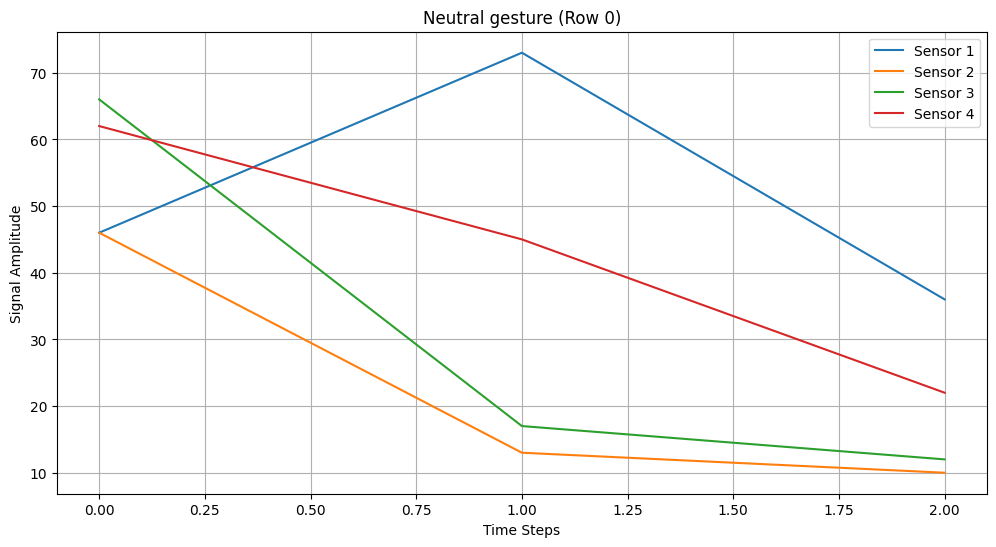

In [14]:
plot_time_signals(neutral_df, row_index=0, title='Neutral gesture')

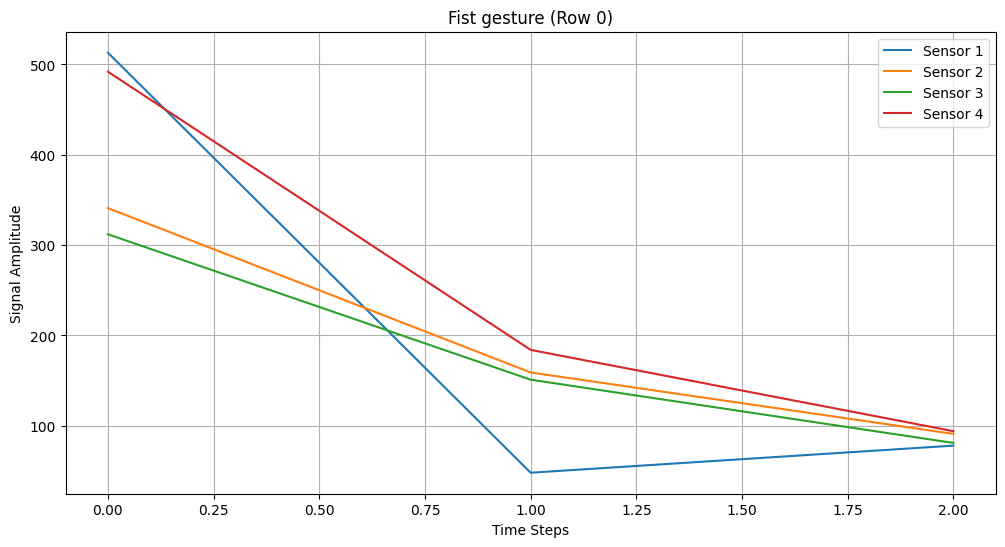

In [15]:
plot_time_signals(fist_df, row_index=0, title='Fist gesture')

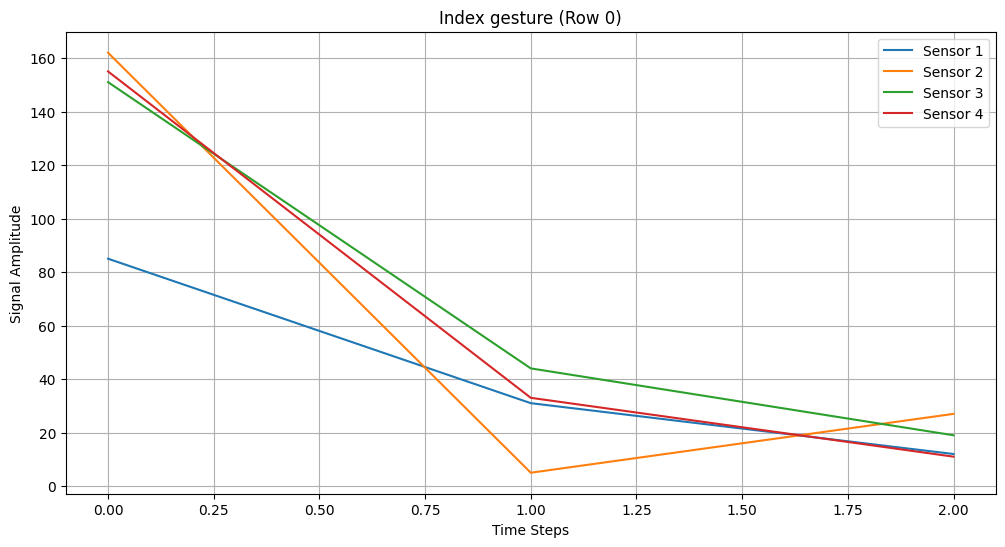

In [16]:
plot_time_signals(index_df, row_index=0, title='Index gesture')

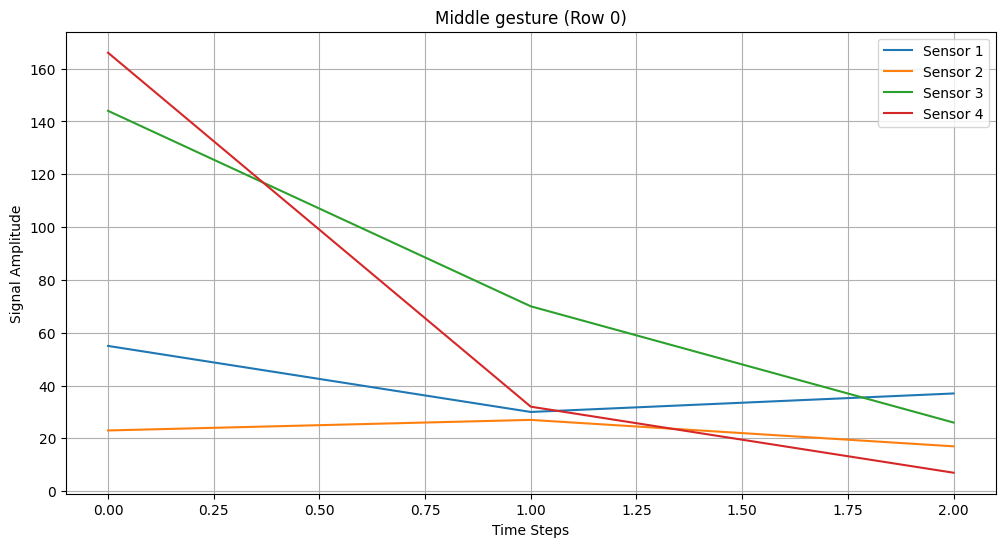

In [17]:
plot_time_signals(middle_df, row_index=0, title='Middle gesture')

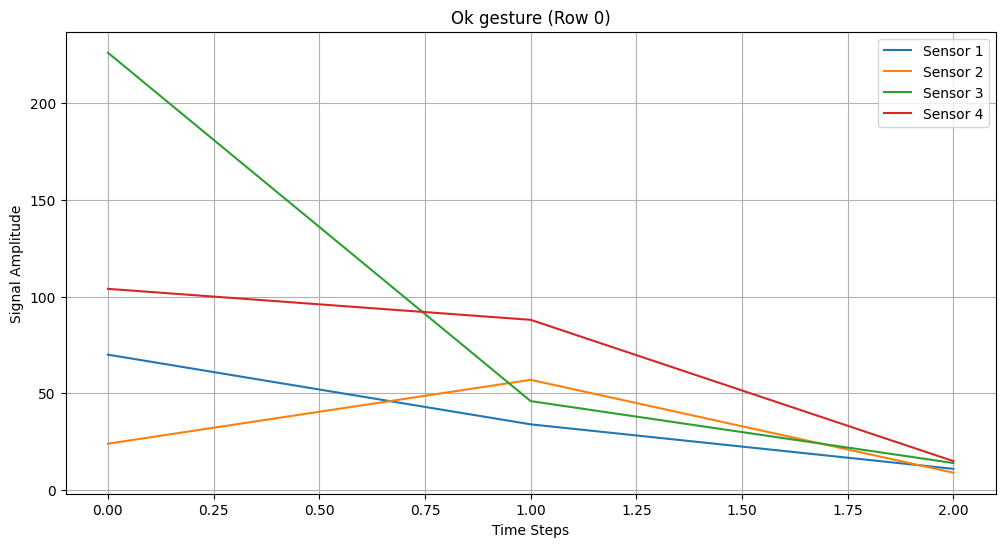

In [18]:
plot_time_signals(ok_df, row_index=0, title='Ok gesture')

In [19]:
if plot_all_timeline:
    plot_all_time_signals(neutral_df, title='Neutral gesture: whole timeline')
    plot_all_time_signals(fist_df, title='Fist gesture: whole timeline')
    plot_all_time_signals(peace_df, title='Peace gesture: whole timeline')
    plot_all_time_signals(ok_df, title='Ok gesture: whole timeline')
    plot_all_time_signals(index_df, title='Index gesture: whole timeline')
    plot_all_time_signals(middle_df, title='Middle gesture: whole timeline')

## Class distribution

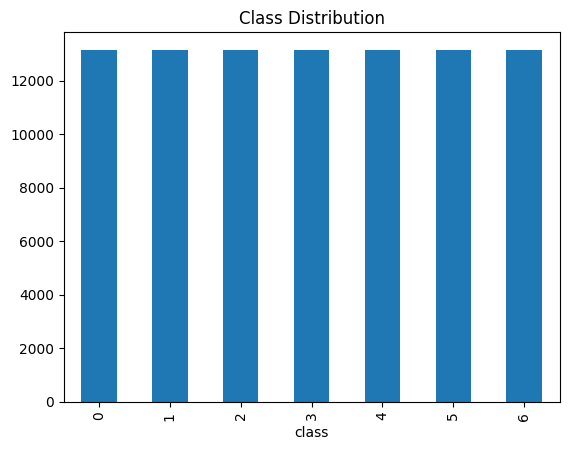

In [20]:
df.iloc[:, -1].value_counts().plot(kind='bar', title="Class Distribution")
plt.show()

## Sensor correlation analysis

/tmp/ipykernel_155979/738033452.py:1: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  sensor_means = sensor_data.groupby(np.arange(sensor_data.shape[1]) // 3, axis=1).mean()


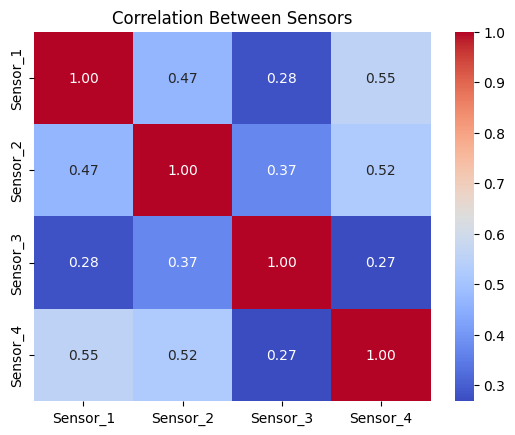

In [22]:
sensor_means = sensor_data.groupby(np.arange(sensor_data.shape[1]) // 3, axis=1).mean()

sensor_means.columns = [f"Sensor_{i+1}" for i in range(4)]

correlation = sensor_means.corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Sensors")
plt.show()

In [27]:
from scipy import signal
from scipy.signal import butter
from numpy import mean, std

lf = 15
hf = 400
fs = 1150
trim = 4*8*5
bandpass_order = 3
outlier_rejection_stds = 6

def _remove_outliers(data):
    data_mean, data_std = mean(data.flatten()), std(data.flatten())
    cut_off = data_std * outlier_rejection_stds
    lower, upper = data_mean - cut_off, data_mean + cut_off

    outliers_removed = [x if x >= lower and x <= upper else 0.0 for x in data]
    return outliers_removed

def _remove_artefact(data):
    data[:trim] = 0
    return data

def preprocess_data(data):
    sos = butter(bandpass_order, (lf, hf), btype="bandpass", fs=fs, output="sos")
    proc_data = signal.sosfilt(sos, data) # f
    return proc_data


## Dimensionality Reduction

In [93]:
# PCA Dimensionality Reduction to 2 components
pca = PCA(n_components=7)
sensor_preproc = preprocess_data(sensor_data)
pca_result = pca.fit_transform(sensor_preproc)

# Plot PCA results
# plt.figure(figsize=(10, 5))
# for class_id in np.unique(labels):
#     plt.scatter(pca_result[labels == class_id, 0], pca_result[labels == class_id, 1], label=f'Class {class_id}', alpha=0.6)
# plt.title("PCA Dimensionality Reduction")
# plt.xlabel("PCA Component 1")
# plt.ylabel("PCA Component 2")
# plt.legend()
# plt.show()

# t-SNE Dimensionality Reduction to 2 components
# tsne = TSNE(n_components=2, perplexity=30, random_state=42)
# tsne_result = tsne.fit_transform(sensor_preproc)

# # Plot t-SNE results
# plt.figure(figsize=(10, 5))
# for class_id in np.unique(labels):
#     plt.scatter(tsne_result[labels == class_id, 0], tsne_result[labels == class_id, 1], label=f'Class {class_id}', alpha=0.6)
# plt.title("t-SNE Dimensionality Reduction")
# plt.xlabel("t-SNE Component 1")
# plt.ylabel("t-SNE Component 2")
# plt.legend()
# plt.show()

## Data Preprocessing

## Spectal Analysis

In [29]:
preprocess = True

def spectral_analysis_overall(dataframe):
    time_steps_per_sensor = dataframe.shape[1] // num_sensors

    # Separate gesture class and sensor data
    gesture_classes = dataframe.iloc[:, -1]
    sensor_data = dataframe.iloc[:, :-1]
    
    # Prepare to store FFT results for each sensor
    fft_results = {f'Sensor_{i+1}': [] for i in range(num_sensors)}

    # Loop over all rows and accumulate FFT results per sensor
    for index, row in sensor_data.iterrows():
        signals = np.array_split(row.values, num_sensors)
        for i, signal in enumerate(signals):
            if preprocess:
                signal = preprocess_data(signal)
            fft_result = np.abs(fft(signal))[:time_steps_per_sensor // 2]  # Positive frequencies only
            fft_results[f'Sensor_{i+1}'].append(fft_result)
    
    # Compute average FFT amplitude for each sensor
    avg_fft_results = {sensor: np.mean(fft_results[sensor], axis=0) for sensor in fft_results}

    # Plot average FFT for each sensor
    plt.figure(figsize=(15, 10))
    for sensor, avg_fft in avg_fft_results.items():
        freqs = fftfreq(time_steps_per_sensor, d=1/fs)[:time_steps_per_sensor // 2]  # Positive frequencies
        plt.plot(freqs, avg_fft, label=sensor)
    
    plt.title("Average Spectral Analysis for All Sensors")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

    # Now analyze by gesture class
    unique_classes = np.unique(gesture_classes)
    plt.figure(figsize=(15, 10))
    for gesture_class in unique_classes:
        class_subset = dataframe[dataframe.iloc[:, -1] == gesture_class]
        class_fft_results = {f'Sensor_{i+1}': [] for i in range(num_sensors)}
        for _, row in class_subset.iloc[:, :-1].iterrows():
            signals = np.array_split(row.values, num_sensors)
            for i, signal in enumerate(signals):
                if preprocess:
                    signal = preprocess_data(signal)
                fft_result = np.abs(fft(signal))[:time_steps_per_sensor // 2]
                class_fft_results[f'Sensor_{i+1}'].append(fft_result)
        # Average across this class
        avg_class_fft = np.mean([np.mean(class_fft_results[sensor], axis=0) for sensor in class_fft_results], axis=0)
        freqs = fftfreq(time_steps_per_sensor, d=1/fs)[:time_steps_per_sensor // 2]
        plt.plot(freqs, avg_class_fft, label=f"Class {gesture_class}")

    plt.title("Average Spectral Analysis by Gesture Class")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.show()

In [30]:
spectral_analysis_overall(df)

KeyboardInterrupt: 

## Train networks

In [24]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [25]:
X = preprocess_data(X)

In [26]:
X.max(), X.min()

(4035.2798093647157, -2545.838363850059)

In [27]:
# from sklearn.preprocessing import RobustScaler
# scaler= RobustScaler()
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [28]:
from pickle import dump
with open("custom_scaler_fft.pkl", "wb") as f:
    dump(scaler, f, protocol=5)

In [29]:
X.max(), X.min()

(29.183834109994244, -31.513623216412643)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

In [31]:
# Count classes in y_test
unique, counts = np.unique(y_test, return_counts=True)
unique, counts

(array([0, 1, 2, 3, 4, 5, 6]),
 array([2617, 2604, 2689, 2633, 2713, 2569, 2599]))

## Classical models

In [76]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=50, max_features='sqrt', max_depth=20, random_state=42) # min_impurity_decrease=0.00005
clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, n_estimators=50, random_state=42)

In [77]:
depths = [estimator.get_depth() for estimator in clf.estimators_]
min(depths), max(depths)

(20, 20)

In [78]:
from pickle import dump
with open("custom_classifier_fft.pkl", "wb") as f:
    dump(clf, f, protocol=5)

In [79]:
y_pred = clf.predict(X_train)
print('Classification Report: \n', classification_report(y_train, y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_train, y_pred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.85      1.00      0.92     10543
           1       1.00      0.96      0.98     10556
           2       0.98      0.92      0.95     10471
           3       1.00      0.96      0.98     10527
           4       0.98      0.98      0.98     10447
           5       0.99      0.96      0.97     10591
           6       0.99      0.99      0.99     10561

    accuracy                           0.97     73696
   macro avg       0.97      0.97      0.97     73696
weighted avg       0.97      0.97      0.97     73696

Confusion Matrix: 
 [[10499     0    13     4    13    13     1]
 [  242 10174    49     6    20    18    47]
 [  751     1  9649    10    28    16    16]
 [  229     1    52 10149    72    15     9]
 [  171     0    32     7 10217     6    14]
 [  354     0    46     7    53 10122     9]
 [   48     0    32    11    32    12 10426]]


In [80]:
y_pred = clf.predict(X_test)

In [81]:
print('Classification Report: \n', classification_report(y_test,y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_test,y_pred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.61      0.85      0.71      2617
           1       0.72      0.56      0.63      2604
           2       0.53      0.43      0.47      2689
           3       0.53      0.46      0.49      2633
           4       0.61      0.65      0.63      2713
           5       0.44      0.44      0.44      2569
           6       0.59      0.64      0.62      2599

    accuracy                           0.58     18424
   macro avg       0.58      0.58      0.57     18424
weighted avg       0.58      0.58      0.57     18424

Confusion Matrix: 
 [[2236    9  145   29   42  140   16]
 [ 145 1462  162  223   77  136  399]
 [ 564  185 1144  251   98  240  207]
 [ 196  159  248 1217  309  325  179]
 [ 169   12  113  134 1752  375  158]
 [ 324   27  199  247  449 1140  183]
 [  52  179  161  192  138  206 1671]]


In [94]:
pca_clf = RandomForestClassifier(n_estimators=50, max_features='sqrt', max_depth=20, random_state=42) # min_impurity_decrease=0.00005
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(pca_result, y, test_size=0.2, shuffle=True, random_state=42)

pca_clf.fit(X_pca_train, y_pca_train)


RandomForestClassifier(max_depth=20, n_estimators=50, random_state=42)

In [95]:
y_pred = pca_clf.predict(X_pca_train)
print('Classification Report: \n', classification_report(y_pca_train, y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_pca_train, y_pred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.80      0.99      0.89     10543
           1       1.00      0.95      0.97     10556
           2       0.96      0.90      0.93     10471
           3       0.99      0.94      0.97     10527
           4       0.97      0.96      0.97     10447
           5       0.98      0.93      0.95     10591
           6       0.99      0.97      0.98     10561

    accuracy                           0.95     73696
   macro avg       0.96      0.95      0.95     73696
weighted avg       0.96      0.95      0.95     73696

Confusion Matrix: 
 [[10462     0    36     4     5    36     0]
 [  325  9991   109    15    31    19    66]
 [  955     1  9404    15    31    35    30]
 [  383     2    81  9931   103    18     9]
 [  258     0    57     6 10076    20    30]
 [  587     1    74    10    96  9808    15]
 [   99     1    70    25    38    44 10284]]


In [96]:
y_pred = pca_clf.predict(X_pca_test)
print('Classification Report: \n', classification_report(y_pca_test, y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_pca_test, y_pred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.53      0.81      0.64      2617
           1       0.65      0.48      0.55      2604
           2       0.37      0.29      0.33      2689
           3       0.41      0.36      0.38      2633
           4       0.55      0.59      0.57      2713
           5       0.32      0.30      0.31      2569
           6       0.52      0.56      0.54      2599

    accuracy                           0.49     18424
   macro avg       0.48      0.49      0.48     18424
weighted avg       0.48      0.49      0.48     18424

Confusion Matrix: 
 [[2122    3  164   48   68  188   24]
 [ 187 1259  204  261   82  155  456]
 [ 668  217  791  313  100  327  273]
 [ 285  193  309  941  359  377  169]
 [ 217   12  118  156 1612  406  192]
 [ 408   31  287  312  538  778  215]
 [ 106  228  241  239  165  176 1444]]


In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

lr_grid = {'max_depth' : [4, 8, 16, 32, 64, 128],
           'criterion' : ['entropy', 'gini']}

clf = RandomForestClassifier(n_estimators=100, max_features='sqrt', random_state=42)

gs = GridSearchCV(estimator=clf, param_grid=lr_grid, cv=5)
gs.fit(X_train, y_train)
y_pred = gs.predict(X_test)

In [38]:
print('Classification Report: \n', classification_report(y_test,y_pred))
print('Confusion Matrix: \n', confusion_matrix(y_test,y_pred))

Classification Report: 
               precision    recall  f1-score   support

           0       0.90      0.95      0.92      6518
           1       0.97      0.94      0.96      6522
           2       0.94      0.94      0.94      6493
           3       0.95      0.95      0.95      5206
           4       0.95      0.95      0.95      5236
           5       0.95      0.94      0.94      5380
           6       0.96      0.93      0.94      5237

    accuracy                           0.94     40592
   macro avg       0.95      0.94      0.94     40592
weighted avg       0.94      0.94      0.94     40592

Confusion Matrix: 
 [[6198   22  113   65   23   75   22]
 [  90 6138   73   56   50   38   77]
 [ 180   35 6128   40   41   36   33]
 [  88   36   44 4966   25   26   21]
 [  91   12   52   34 4961   58   28]
 [ 144   15   45   30   66 5052   28]
 [ 105   56   62   52   38   49 4875]]


In [39]:
from pickle import dump
with open("custom_classifier_gen2.pkl", "wb") as f:
    dump(gs, f, protocol=5)

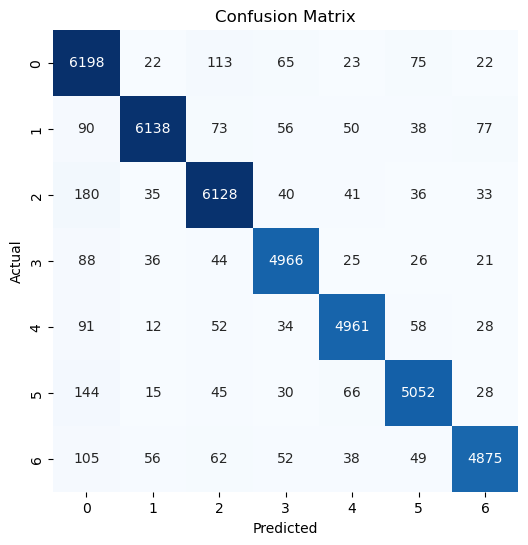

In [40]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Deep Learning

In [38]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [39]:
class NeuralNet(nn.Module):
    def __init__(self, input_size, output_size):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 1024)
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(1024, 1024)
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(1024, output_size)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.softmax(self.fc3(x), dim=1)
        return x

In [42]:
input_size = X_train.shape[1]
output_size = 7
batch_size = 256
epochs = 400
learning_rate = 0.001

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

ff_model = NeuralNet(input_size, output_size)
criterion = nn.CrossEntropyLoss()  # Sparse categorical cross-entropy
optimizer = optim.Adam(ff_model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ff_model.to(device)

NeuralNet(
  (fc1): Linear(in_features=12, out_features=1024, bias=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=1024, out_features=1024, bias=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=1024, out_features=7, bias=True)
)

In [43]:
for epoch in range(epochs):
    ff_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = ff_model(inputs)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        # Compute running loss and accuracy
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    scheduler.step(running_loss / total)
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = correct / total * 100
    
    ff_model.eval()
    with torch.no_grad():
        X_test_tensor = X_test_tensor.to(device)
        y_test_tensor = y_test_tensor.to(device)
        outputs = ff_model(X_test_tensor)
        _, predicted = outputs.max(1)
        test_accuracy = predicted.eq(y_test_tensor).sum().item() / y_test_tensor.size(0) * 100
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%")

Epoch 1/400, Loss: 1.7112, Accuracy: 44.31%, Test Accuracy: 45.92%
Epoch 2/400, Loss: 1.6919, Accuracy: 46.43%, Test Accuracy: 46.03%
Epoch 3/400, Loss: 1.6902, Accuracy: 46.53%, Test Accuracy: 47.01%
Epoch 4/400, Loss: 1.6861, Accuracy: 47.08%, Test Accuracy: 47.04%
Epoch 5/400, Loss: 1.6853, Accuracy: 47.10%, Test Accuracy: 46.90%
Epoch 6/400, Loss: 1.6822, Accuracy: 47.44%, Test Accuracy: 47.70%
Epoch 7/400, Loss: 1.6818, Accuracy: 47.53%, Test Accuracy: 47.54%
Epoch 8/400, Loss: 1.6807, Accuracy: 47.59%, Test Accuracy: 46.91%
Epoch 9/400, Loss: 1.6800, Accuracy: 47.67%, Test Accuracy: 47.16%
Epoch 10/400, Loss: 1.6772, Accuracy: 48.00%, Test Accuracy: 47.38%
Epoch 11/400, Loss: 1.6780, Accuracy: 47.93%, Test Accuracy: 47.43%
Epoch 12/400, Loss: 1.6757, Accuracy: 48.22%, Test Accuracy: 47.69%
Epoch 13/400, Loss: 1.6745, Accuracy: 48.34%, Test Accuracy: 47.42%
Epoch 14/400, Loss: 1.6752, Accuracy: 48.33%, Test Accuracy: 47.55%
Epoch 15/400, Loss: 1.6736, Accuracy: 48.46%, Test Accura

In [44]:
torch.save(ff_model.state_dict(), 'custom_nn_fft.pth')

In [45]:
ff_model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    y_test_tensor = y_test_tensor.to(device)
    outputs = ff_model(X_test_tensor)
    _, predicted = outputs.max(1)
    test_accuracy = predicted.eq(y_test_tensor).sum().item() / y_test_tensor.size(0) * 100

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 49.72%


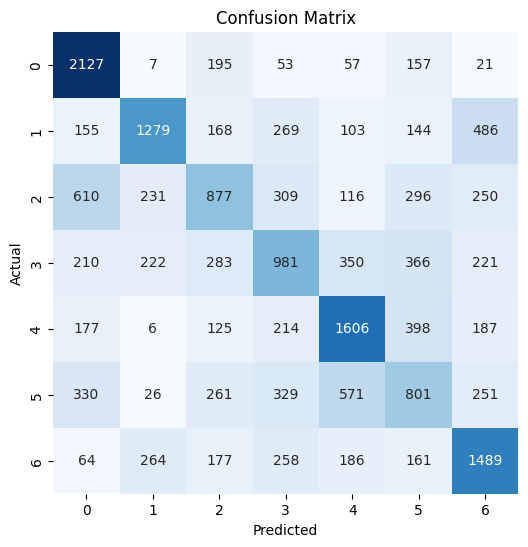

In [46]:
cm = confusion_matrix(y_test, predicted.cpu())

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [47]:
class PureLSTM(nn.Module):
    
    def __init__(self, n_features, n_hidden, n_sequence, n_layers, n_classes):
        super(PureLSTM, self).__init__()
        
        self.n_features = n_features
        self.n_hidden = n_hidden
        self.n_sequence = n_sequence
        self.n_layers = n_layers
        self.n_classes = n_classes
        
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=n_hidden, num_layers=n_layers, batch_first=True)
        
        self.linear_1 = nn.Linear(in_features=n_hidden, out_features=128)
        self.dropout_1 = nn.Dropout(p=0.2)
        
        self.linear_2 = nn.Linear(in_features=128, out_features=n_classes)        
        
    
    def forward(self, x):
        
        self.hidden = (
            torch.zeros(self.n_layers, x.shape[0], self.n_hidden).to(device),
            torch.zeros(self.n_layers, x.shape[0], self.n_hidden).to(device)
        )
    
        out, (hs, cs) = self.lstm(x.view(len(x), self.n_sequence, -1),self.hidden)
        out = out[:,-1,:]

        out = self.linear_1(out)
        out = self.dropout_1(out)
        out = self.linear_2(out)
        
        return out
    
def train_model(model, train_dataloader, n_epochs):
    global X_test_tensor, y_test_tensor
    
    running_loss = 0.0
    correct = 0
    total = 0
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer)
    
    for epoch in range(n_epochs):
        model.train()
        for i, (inputs, labels) in enumerate(train_dataloader):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            
            loss = loss_fn(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Compute running loss and accuracy
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        scheduler.step(running_loss / total)
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_accuracy = correct / total * 100
        
        model.eval()
        with torch.no_grad():
            X_test_tensor = X_test_tensor.to(device)
            y_test_tensor = y_test_tensor.to(device)
            outputs = model(X_test_tensor)
            _, predicted = outputs.max(1)
            test_accuracy = predicted.eq(y_test_tensor).sum().item() / y_test_tensor.size(0) * 100

        print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%")
        
    return model

In [48]:
n_features = X_train.shape[1]
n_sequence=1
# n_features = 4
# n_sequence=8
n_hidden=32*3
n_layers=2
epochs = 400

model = PureLSTM(n_features, n_hidden, n_sequence, n_layers, output_size).to(device)
print("Train Data Shape ",X_train.shape, y_train.shape)
print("Test Data Shape ",X_test.shape, y_test.shape)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
# X_train_tensor = X_train_tensor.view(-1, n_sequence, n_features)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Train Data Shape  (73696, 12) (73696,)
Test Data Shape  (18424, 12) (18424,)


PureLSTM(
  (lstm): LSTM(12, 96, num_layers=2, batch_first=True)
  (linear_1): Linear(in_features=96, out_features=128, bias=True)
  (dropout_1): Dropout(p=0.2, inplace=False)
  (linear_2): Linear(in_features=128, out_features=7, bias=True)
)

In [49]:
model = train_model(model, train_loader, n_epochs = epochs)

Epoch 1/400, Loss: 1.5363, Accuracy: 40.47%, Test Accuracy: 45.10%
Epoch 2/400, Loss: 2.9458, Accuracy: 42.99%, Test Accuracy: 46.19%
Epoch 3/400, Loss: 4.3411, Accuracy: 44.04%, Test Accuracy: 46.36%
Epoch 4/400, Loss: 5.7275, Accuracy: 44.64%, Test Accuracy: 46.69%
Epoch 5/400, Loss: 7.1082, Accuracy: 45.05%, Test Accuracy: 46.93%
Epoch 6/400, Loss: 8.4857, Accuracy: 45.34%, Test Accuracy: 47.10%
Epoch 7/400, Loss: 9.8599, Accuracy: 45.56%, Test Accuracy: 47.09%
Epoch 8/400, Loss: 11.2304, Accuracy: 45.73%, Test Accuracy: 47.35%
Epoch 9/400, Loss: 12.5995, Accuracy: 45.87%, Test Accuracy: 46.73%
Epoch 10/400, Loss: 13.9660, Accuracy: 46.00%, Test Accuracy: 47.31%
Epoch 11/400, Loss: 15.3302, Accuracy: 46.12%, Test Accuracy: 47.49%
Epoch 12/400, Loss: 16.6927, Accuracy: 46.20%, Test Accuracy: 47.13%
Epoch 13/400, Loss: 18.0538, Accuracy: 46.29%, Test Accuracy: 47.35%
Epoch 14/400, Loss: 19.4136, Accuracy: 46.36%, Test Accuracy: 47.57%
Epoch 15/400, Loss: 20.7716, Accuracy: 46.43%, Tes

In [50]:
torch.save(model.state_dict(), 'custom_lstm_fft.pth')

def evaluateModel(outputs, y):
    _, predicted = outputs.max(1)
    test_accuracy = predicted.eq(y).sum().item() / y.size(0) * 100
    return test_accuracy, predicted

model.eval()
with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    y_test_tensor = y_test_tensor.to(device)
    y_hat_test = model(X_test_tensor)
    acc, predicted = evaluateModel(y_hat_test, y_test_tensor)
    print(f"Test Accuracy: {acc:.2f}%")

Test Accuracy: 47.03%


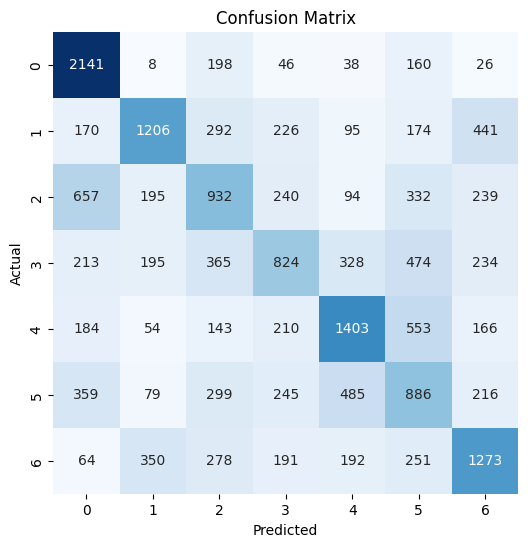

In [51]:
cm = confusion_matrix(y_test, predicted.cpu())

plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Feature engineering